In [1]:
# Reload code outside notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

In [2]:
import os
import h5py
import scipy
import wotan
import numpy as np
import pandas as pd
from tqdm import tqdm

from matplotlib import pyplot as plt
import matplotlib.colors  as colors
import matplotlib.patches as patches

from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord

from scipy.signal import periodogram
from scipy.ndimage import median_filter
from scipy.interpolate import interp2d

# PlatoSim
import platosim.referenceFrames as rf
import platosim.plot            as pt
import platosim.utilities       as ut
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

## Fetch simulation

In [85]:
# Load all data for a single star
# idir = "/lhome/nicholas/data/platosimPaper/SunEarth_Tran"
# idir = "/lhome/nicholas/data/platosimPaper/SunEarth_TranGranPuls"
idir = "/lhome/nicholas/data/platosimPaper/SunNeptune_Tran"
# idir = "/lhome/nicholas/data/platosimPaper/SunNeptune_TranGranPuls"
lcs = LightCurve(idir, mode="multi")

In [64]:
# Unzip all compressed files for the same star
lcs.unpack()

In [87]:
# Fetch all feather filenames
filenames = lcs.files("ftr")

## Test with single camera and quarter

In [88]:
# Check filename
filename  = filenames[0]
filename

'/lhome/nicholas/data/platosimPaper/SunNeptune_Tran/000000001_Ncam1.1_Q1.ftr'

In [89]:
# Fetch the first light curve for this star
lc = LightCurve(filename)
lc.data().head()

,index,time,flux,cx,cy,bg,flux_err,cx_err,cy_err,bg_err,chi2,iter,lamb
0,0,18.75,405150.443194,2.875428,3.162343,2011.639834,683.073301,0.001012,0.000989,12.650649,1.786234,5,333.333333
1,1,43.75,406216.637399,2.876386,3.163009,2036.246011,684.017870,0.001013,0.000987,12.684424,1.341262,5,0.370370
2,2,68.75,406353.946221,2.876931,3.160937,2012.293283,684.035690,0.001013,0.000985,12.654767,0.767968,5,0.012346
3,3,93.75,405525.215584,2.880727,3.159379,2014.728725,683.345686,0.001019,0.000987,12.654026,1.773490,6,0.123457
4,4,118.75,406598.588930,2.881157,3.162996,2015.659937,684.234285,0.001018,0.000986,12.659308,1.175573,6,0.123457


<IPython.core.display.Javascript object>


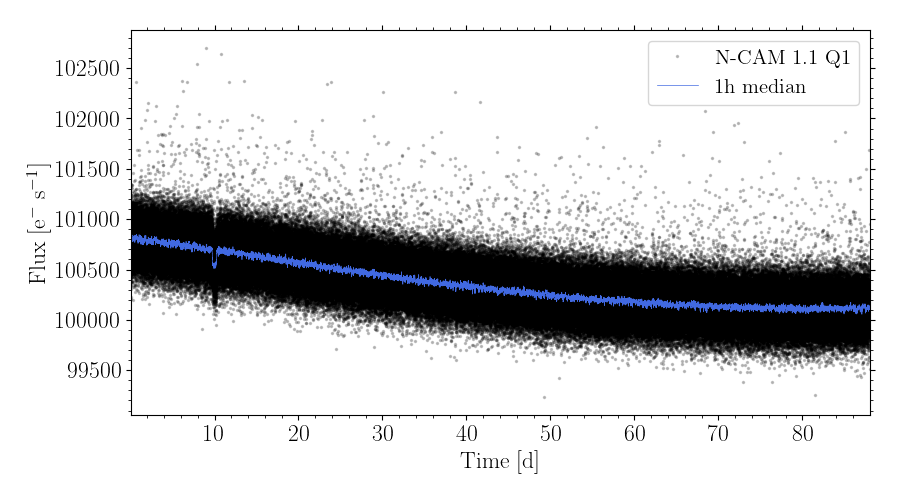

In [90]:
# Plot the simulation, running median, and binned data
fig, ax = lc.plot(time_unit="d", median_filter=1);

In [10]:
# Get noise-less lightv curve
lc_var = lc.varsource()
lc_var.head()

,time,tran,occu,beam,elli,comb,spot,gran,puls
0,0.0,0.0,0.0,0.003209,-0.000005,0.0,0.0,0.0,0.0
1,25.0,0.0,0.0,0.003208,-0.000005,0.0,0.0,0.0,0.0
2,50.0,0.0,0.0,0.003208,-0.000005,0.0,0.0,0.0,0.0
3,75.0,0.0,0.0,0.003208,-0.000005,0.0,0.0,0.0,0.0
4,100.0,0.0,0.0,0.003208,-0.000005,0.0,0.0,0.0,0.0


<IPython.core.display.Javascript object>


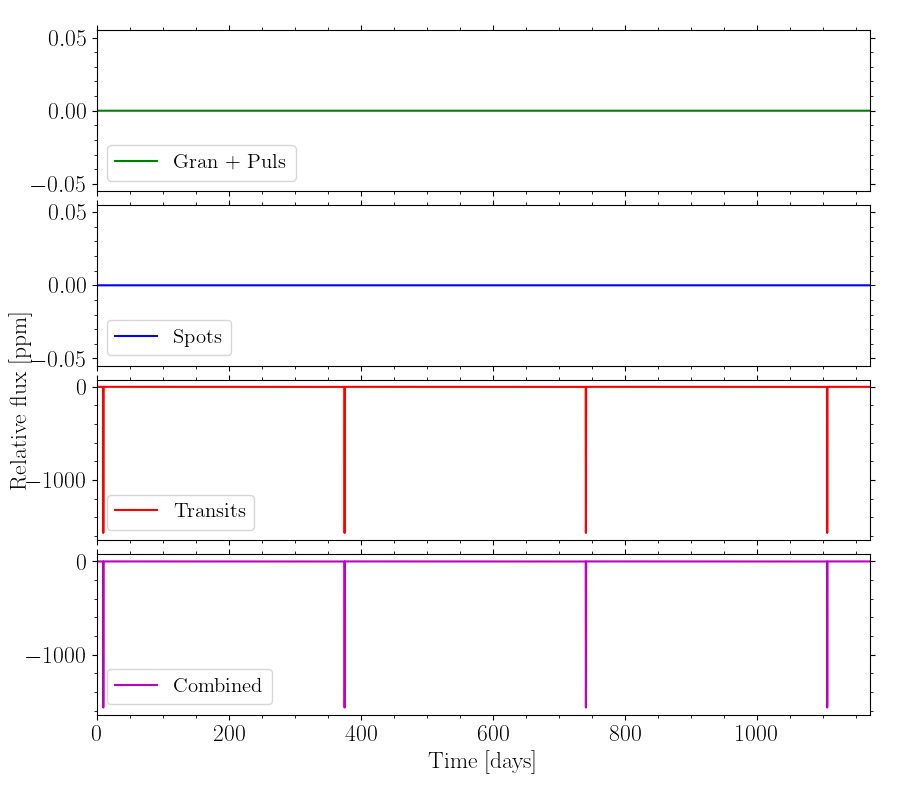

In [11]:
# Plot the input noise-less light curve
fig, ax = lc.plot_varsource();

### Detrend using a simple **Polynomial**

<IPython.core.display.Javascript object>


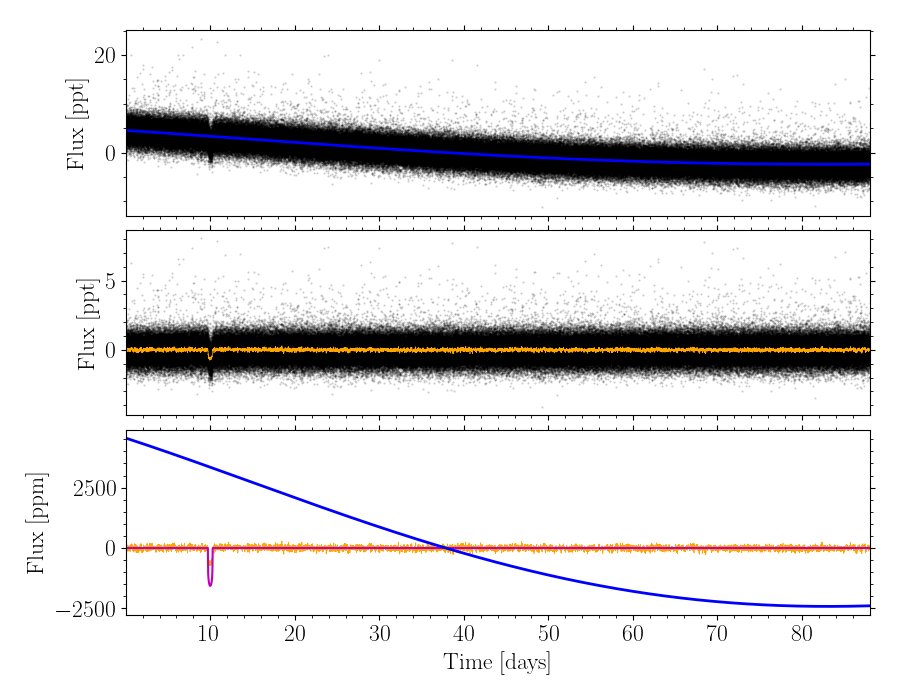

In [77]:
df = lc.detrend(model="poly", poly_deg=4, plot=True)

### Detrending with **Wotan**

The software Wotan is implemented into the detrending module of the `LightCurve` class. We use the robust fitting method cosine description. Note that the detrending works best if you in priori known the full transit time of the planet (i.e. from contact point 1 to 4). We here calculate this period and use is a `window_lenght` detrend criteria:

In [78]:
P = 365.25
t0 = 10
tdur = wotan.t14(R_s=1, M_s=1, P=P, small_planet=True)
print(f'Transit duration : {tdur*24:.2f} hours')
tdur*3

Transit duration : 12.97 hours


1.6214770744154146

<IPython.core.display.Javascript object>


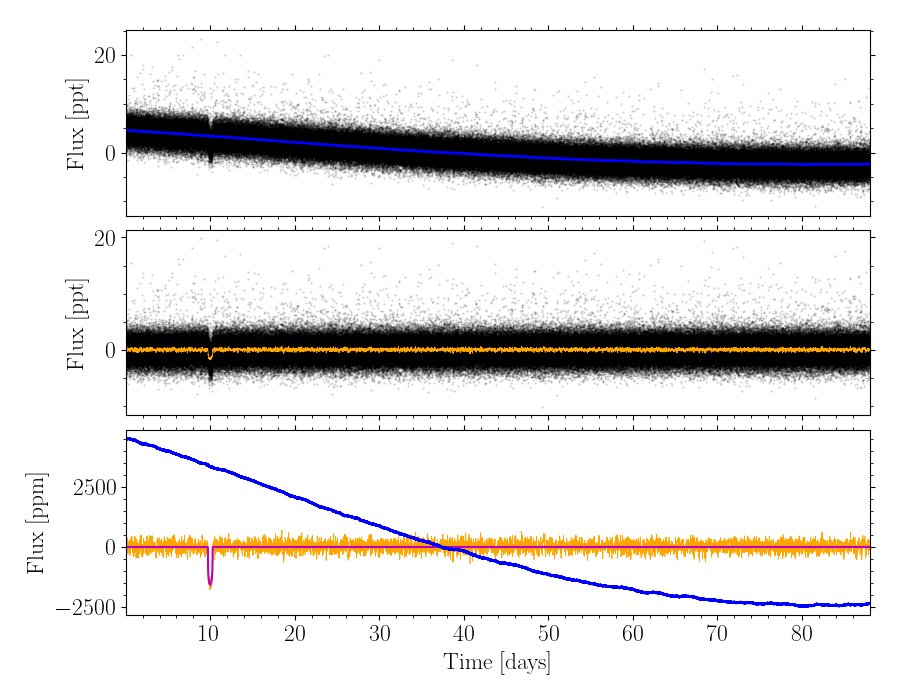

In [91]:
df = lc.detrend(model="wotan", window=3*tdur, mask=[P, tdur, t0], plot=True)

In [79]:
# lc.plot_detrend(df);

### Outlier rejection after detrending

<IPython.core.display.Javascript object>


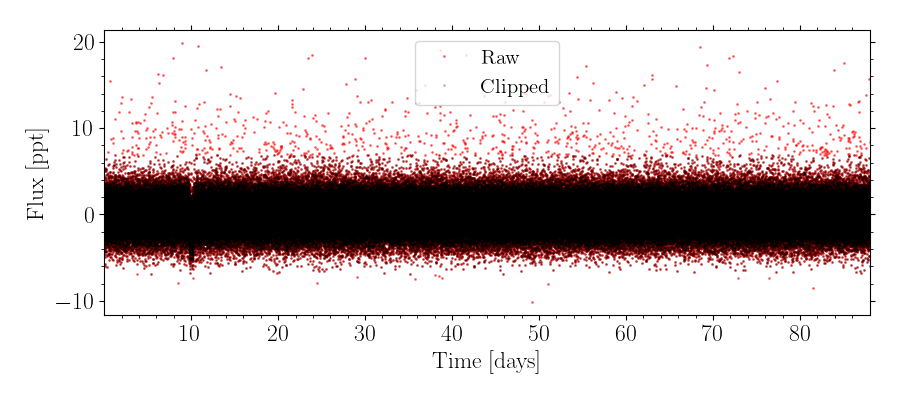

In [97]:
df = lc.clip(model='sigma', window=3*tdur, low=4, high=4, plot=True)

## All cameras for a single star

<IPython.core.display.Javascript object>


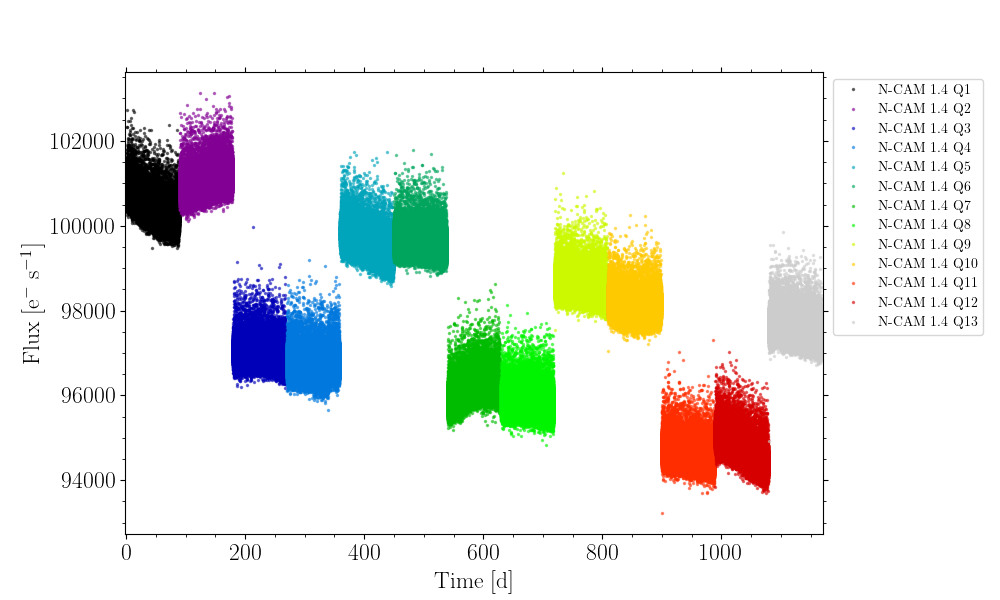

In [98]:
# Plot all light curves but for specific group, camera, or quarter
lcs.plot_multi(group=1, camera=4, quarter=False, flux_unit="e/s");

## Detrend and Merge light curves for single star

In [1]:
# df = lcs.merge(detrend=[3*tdur, P, tdur, t0], filename='lc_SunNeptune_Tran')

In [10]:
lc = LightCurve('lightcurve_detrended_merged.ftr')
df = lc.data()
df

,time,flux,flux_err
0,0.000000,-445.964260,-1420.303062
1,0.000000,-386.798830,-1290.470288
2,0.000000,1548.479028,-650.959954
3,0.000000,-2405.239986,-2049.324639
4,0.000000,265.113124,-749.536169
...,...,...,...
112223227,1437.999928,1132.407108,-239.019825
112223228,1437.999928,1325.691698,-3.658946
112223229,1437.999928,-167.572723,-1557.086114
112223230,1437.999928,1376.342765,427.286275


In [11]:
df = df[df.time < 760]

In [59]:
df

,time,flux,flux_err
0,0.000000,-445.964260,-1420.303062
1,0.000000,-386.798830,-1290.470288
2,0.000000,1548.479028,-650.959954
3,0.000000,-2405.239986,-2049.324639
4,0.000000,265.113124,-749.536169
...,...,...,...
59277307,759.999928,-2142.380596,-710.637697
59277308,759.999928,-856.760369,-485.253063
59277309,759.999928,1505.306571,516.287562
59277310,759.999928,720.855274,453.243544


In [62]:
# Mean the same times
df_mean = df.groupby('time').mean().reset_index()

In [65]:
df_mean / 1e6 + 1 

,time,flux,flux_err
0,1.00000,0.999782,0.998893
1,1.00000,0.999816,1.000771
2,1.00000,0.999296,0.997658
3,1.00000,1.000034,0.998651
4,1.00000,1.006819,1.002096
...,...,...,...
10285051,1.00076,1.003446,1.001577
10285052,1.00076,0.999201,0.999761
10285053,1.00076,0.999861,0.999928
10285054,1.00076,1.000735,1.000589


In [66]:
df_mean.flux = df_mean.flux / 1e6 + 1

<IPython.core.display.Javascript object>


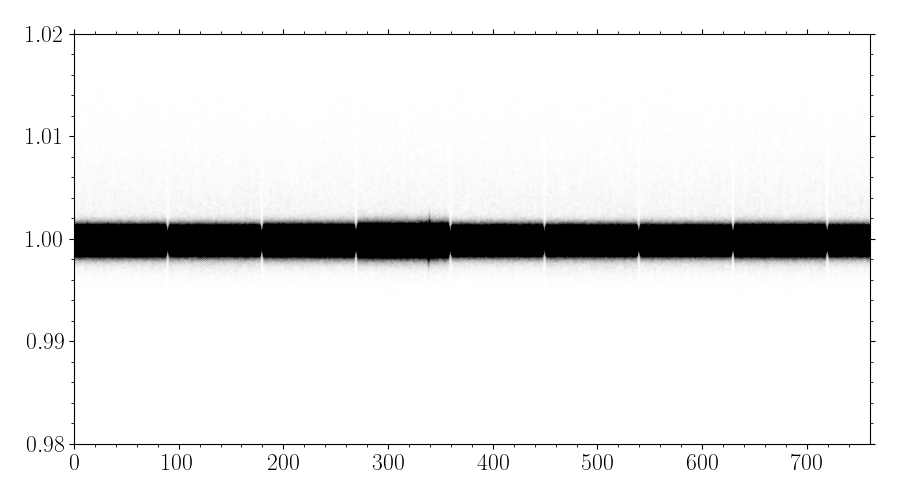

In [78]:
plt.figure(figsize=(9,5))
x = 100
# plt.plot(df.time.iloc[::x], df.flux.iloc[::x], 'k.', ms=0.05, alpha=1)
plt.plot(df_mean.time, df_mean.flux, 'k.', ms=0.01, alpha=0.5)
# plt.plot(df['time'], lc_med, 'b-', alpha=0.8)
# for i in range(1, int(4*4)):plt.axvline(i*90)
    
plt.xlim(np.min(df.time), np.max(df.time))
plt.ylim(0.98, 1.02)
plt.tight_layout();

In [69]:
from transitleastsquares import transitleastsquares
model = transitleastsquares(df_mean.time, df_mean.flux)
results = model.power(R_star_min=0.9, R_star_max=1.1, 
                      M_star_min=0.9, M_star_max=1.1, 
                      period_min=350., period_max=380., 
                      use_threads=10)

Transit Least Squares TLS 1.0.31 (22 Nov 2021)
Creating model cache for 29 durations
Searching 10285055 data points, 348 periods from 350.007 to 380.0 days
Using 10 of 12 CPU threads


100%|████████████████████████████████████████████| 348/348 periods | 30:56<00:00
/lhome/nicholas/.cache/pypoetry/virtualenvs/platosim-IXVcDOIs-py3.8/lib/python3.9/site-packages/transitleastsquares/main.py:205: UserWarning: No transit were fit. Try smaller "transit_depth_min"
  warnings.warn('No transit were fit. Try smaller "transit_depth_min"')


<IPython.core.display.Javascript object>


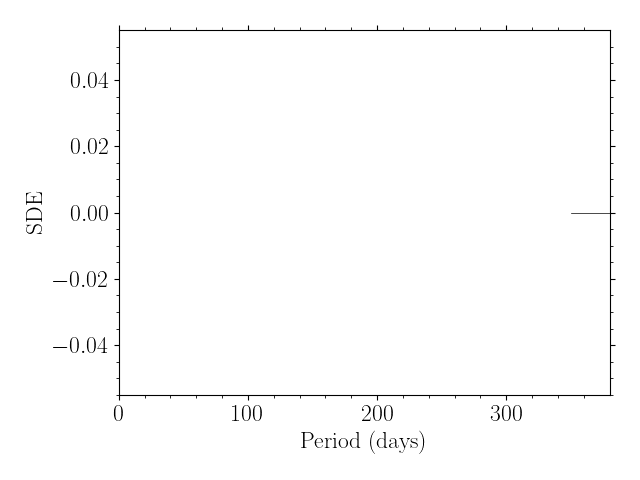

In [73]:
plt.figure()
ax = plt.gca()
ax.axvline(results.period, alpha=0.4, lw=3)
plt.xlim(np.min(results.periods), np.max(results.periods))
for n in range(2, 10):
    ax.axvline(n*results.period, alpha=0.4, lw=1, linestyle="dashed")
    ax.axvline(results.period / n, alpha=0.4, lw=1, linestyle="dashed")
plt.ylabel(r'SDE')
plt.xlabel('Period (days)')
plt.plot(results.periods, results.power, color='black', lw=0.5)
plt.xlim(0, max(results.periods))
plt.tight_layout()

In [ ]:
plt.figure()
plt.plot(results.model_folded_phase, results.model_folded_model, color='red')
plt.scatter(results.folded_phase, results.folded_y, color='blue', s=10, alpha=0.5, zorder=2)
plt.xlim(0.48, 0.52)
plt.xlabel('Phase')
plt.ylabel('Relative flux');